# Photometry of M16
## Importing Modules and Libraries

In [2]:
#import packages 

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from astropy.time import Time
import astropy.units as u
import urllib.request
import os
import gzip
import shutil
from astropy.io import fits


## Downloading FITS Image of M16

In [1]:
from astropy.utils.data import download_file

m16_url = "https://mast.stsci.edu/api/v0.1/Download/file/?uri=mast:HST/product/idnm29ytq_drz.fits" #URL of M16 image from the MAST Archive 
m16_file = download_file(m16_url, cache = True)
m16_file 
#"https://opencomputinglab.github.io/SubjectMatterNotebooks/astronomy/fits-images.html"

'C:\\Users\\mya\\.astropy\\cache\\download\\url\\f8cf98df576c56953cbeb544353cc99a\\contents'

## Image Display of M16 Region

In [3]:
m16_hdu_list = fits.open(m16_file) 
if 'm16.fits' not in os.listdir():
    m16_hdu_list.writeto('m16.fits')

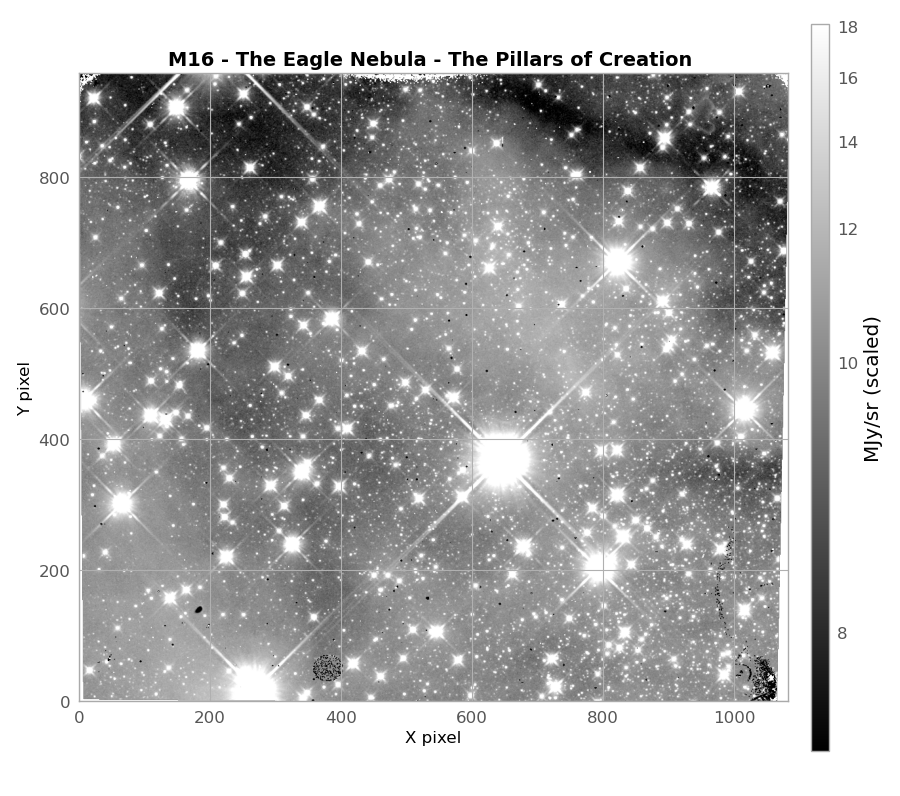

In [9]:
#Nice styling
from astropy.visualization import astropy_mpl_style
plt.style.use(astropy_mpl_style)

m16_data = fits.getdata('m16.fits')

#Display the image
#plt.imshow(image_data, cmap='gray')
#plt.colorbar();
#Lecture 14
if os.path.exists(m16_file) and m16_data is not None:
    from astropy.visualization import ZScaleInterval, AsinhStretch, ImageNormalize
    
    # Combine interval (ZScale finds optimal min/max) with stretch (AsinhStretch compresses dynamic range)
    norm = ImageNormalize(m16_data, 
                          interval=ZScaleInterval(),
                          stretch=AsinhStretch())
    
    # Calculate figure size maintaining aspect ratio
    aspect_ratio = m16_data.shape[0] / m16_data.shape[1]
    fig_width = 9
    fig_height = fig_width * aspect_ratio
    
    plt.figure(figsize=(fig_width, fig_height))
    
    # origin='lower' puts (0,0) at bottom-left (astronomical convention)
    plt.imshow(m16_data, cmap='gray', origin='lower', norm=norm)
    plt.colorbar(label='MJy/sr (scaled)', fraction=0.03, pad=0.03, aspect=40)
    plt.title('M16 - The Eagle Nebula - The Pillars of Creation ', 
              fontsize=14, fontweight='bold')
    plt.xlabel('X pixel', fontsize=12)
    plt.ylabel('Y pixel', fontsize=12)
    plt.tight_layout()
    plt.show()
elif os.path.exists(m16_file):
    print("Skipping visualization - no image data loaded")

## Star Detection and PSF Fitting

In [13]:
from astropy.stats import sigma_clipped_stats 
import photutils
from photutils.detection import DAOStarFinder
mean,median,std=sigma_clipped_stats(m16_data, sigma=3.0) #ignores outliers and NaNs 
print(mean,median,std)

daofind=DAOStarFinder(fwhm=3.0,threshold=5*std) #width of PSF fit (in pixels), absolute image value above which to select sources
# find sources
sources=daofind(m16_data-median) #median (?) values of M16 DAO stats
sources

9.960842 9.955563 1.1637075


id,x_centroid,y_centroid,sharpness,roundness1,roundness2,n_pixels,peak,flux,mag,daofind_mag
int64,float64,float64,float64,float32,float64,int64,float32,float32,float32,float64
1,513.9031613130381,0.24899927410070835,0.7134274434016479,0.73040944,0.645589082323234,25,6.990198,5.0858507,-1.7659091,-0.32525072576141817
2,531.244923398953,0.7242084156717052,0.5570064105140807,-0.5596071,-0.4302496129471298,25,6.4244003,33.142887,-3.800976,-0.0630726861460992
3,640.3802391165789,1.507574418006386,0.6470048232320408,0.673943,0.12822422128700103,25,13.354204,69.563126,-4.6059475,-0.7253815941500346
4,689.880822165965,2.1507383678415763,0.7034356503292205,-0.07083377,-0.06521381944696207,25,7.1584435,32.006096,-3.7630818,-0.038558766333971733
5,889.1285480685689,1.6852632918270505,0.600553106129291,0.1733785,0.05131582371828351,25,7.8709087,46.877056,-4.1774006,-0.18219432394207313
6,1000.5139633724588,1.667521948390524,0.6897895149235104,-0.5610327,-0.3384302375249362,25,14.733271,84.8105,-4.821124,-0.7314249550216299
7,341.4690704170448,4.089008725377353,0.6978766835594474,-0.16265784,-0.07101482391511271,25,2963.7134,13537.954,-10.328883,-6.570118288198742
8,717.8394981175869,4.186415498954901,0.6496538023839602,-0.69771636,-0.17126609028904435,25,64.53616,353.8478,-6.372041,-2.4174489455072092
9,726.5364657641597,4.4396614590810115,0.5265484142955668,0.39196274,-0.21315151654697473,25,130.2923,811.4805,-7.2731953,-3.3073912703625776


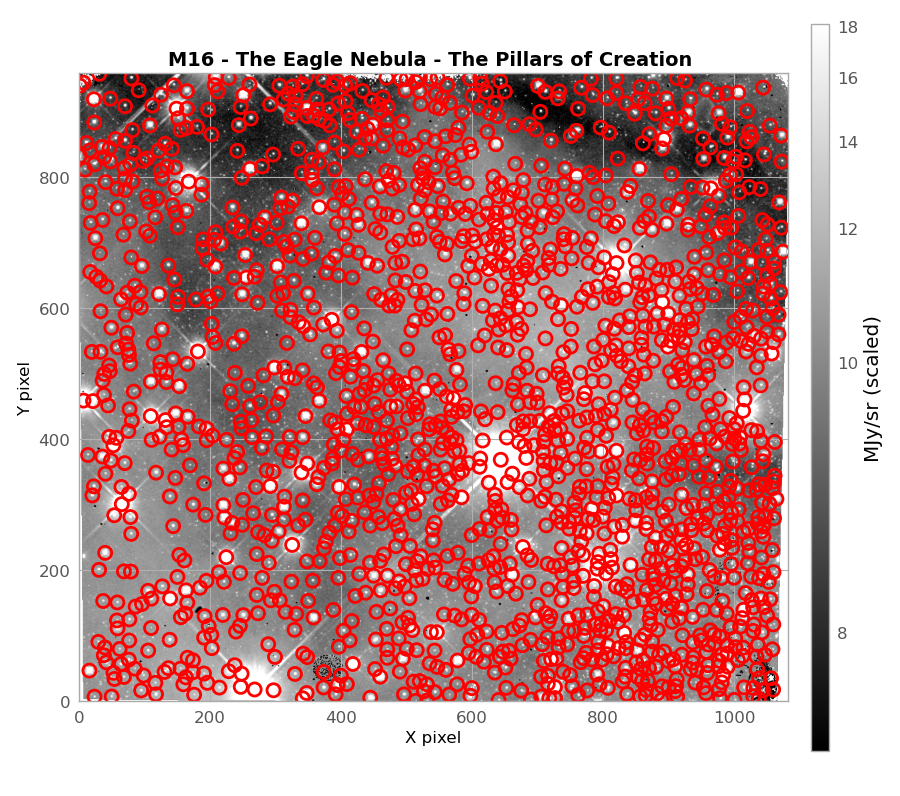

In [14]:
%matplotlib widget
from photutils.aperture import CircularAperture #code from DESI ASTRO 
positions = np.transpose((sources['xcentroid'],sources['ycentroid'])) #positions of stars from sources
plt.figure(figsize=(fig_width, fig_height))
apertures=CircularAperture(positions,r=10) #apertures around sources
apertures.plot(color='red',lw=2)

#image display


plt.imshow(m16_data, cmap='gray', origin='lower', norm=norm)
plt.colorbar(label='MJy/sr (scaled)', fraction=0.03, pad=0.03, aspect=40)
plt.title('M16 - The Eagle Nebula - The Pillars of Creation ', 
            fontsize=14, fontweight='bold')
plt.xlabel('X pixel', fontsize=12)
plt.ylabel('Y pixel', fontsize=12)
plt.tight_layout()
plt.show()

### PSF Fitting 

,xposition,yposition
0,121.8,621.8
1,167.4,793.5
2,234.9,753.4
3,890.6,609.2
4,764.4,501.1


,xposition,yposition
0,121.8,621.8


ValueError: Input position contains invalid values (NaNs or infs).

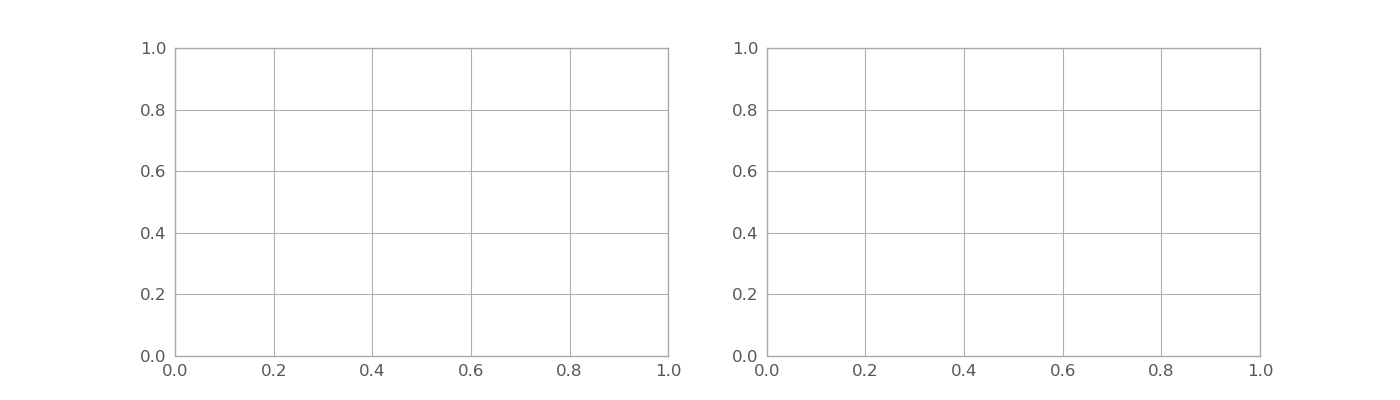

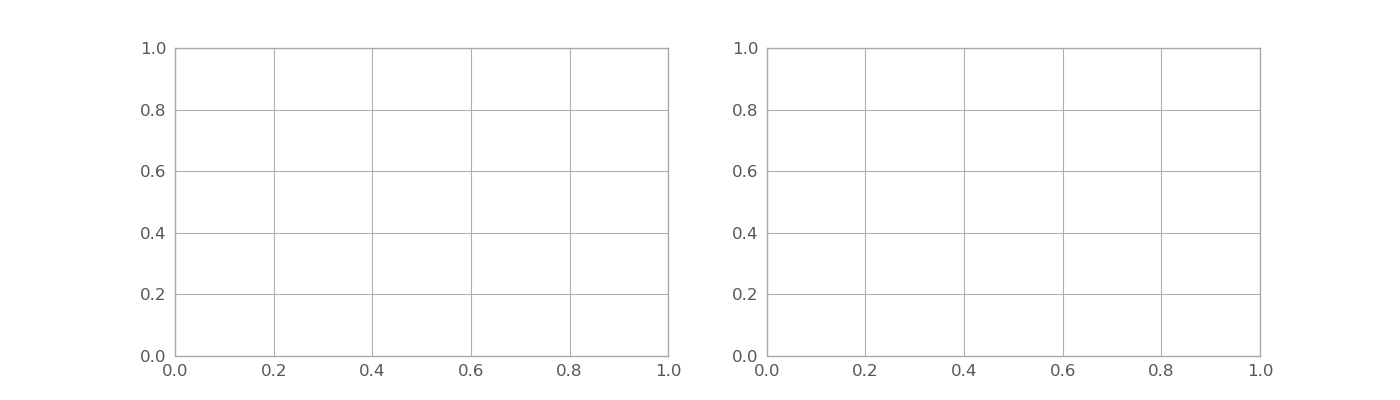

In [ ]:
from astropy.nddata.utils import Cutout2D
pixels = 15 
size = (pixels,pixels)


fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sigma = 3.0
fwhm = 2.355 * sigma 

# PSF Fit of 2D image

#xposition_array = np.array([121.8, 167.4, 234.9, 890.6, 764.4]) #initally tried a 2D array
#yposition_array = np.array([621.8, 793.5, 753.4, 609.2, 501.1])
position_data = {"xposition": [121.8, 167.4, 234.9, 890.6, 764.4], "yposition": [621.8, 793.5, 753.4, 609.2, 501.1]}
pos_df = pd.DataFrame.from_dict(position_data)
display(pos_df)
display(pos_df[0:1])
# Do we need cross-section through center?
fig, axs = plt.subplots(1,2, figsize=(14, 4)) 
axs=axs.flatten()
for p in range(len(pos_df)): #instead of calling sources, create a list or array with the positions of specific stars , https://jakevdp.github.io/PythonDataScienceHandbook/04.08-multiple-subplots.html
    cutout=Cutout2D(m16_data.data, (pos_df), size) #cutout portion of image using fitted position values from the table above 
    minim=np.nanpercentile(cutout.data, 50) #____________
    maxim=np.nanpercentile(cutout.data, 99.9)
    im1 = axes[0].imshow(cutout.data, origin='lower', cmap='gray', vmin=minim, vmax=maxim, norm='log') #______________________
    
fig.supxlabel('Y [pixels]', fontsize=12)  
fig.supylabel('X [pixels]', fontsize=12)
fig.suptitle('PSF Fit for 10 stars in M16', fontsize=15) 
plt.savefig('PSF Fit for 10 stars in M16.png')

plt.show()

#2D residuals data-psf model fit OR  radial profile / model  
# star 1- Cluseranalyszer(filename, x,y)
#star1.fitpsf()
#star1.showfit()

### Starter code for cutout image display

In [47]:
cutout=Cutout2D(m16_data.data, (121.8,621.6), size) #cutout portion of image using fitted position values from the table above 
minim=np.nanpercentile(cutout.data, 50) #____________
maxim=np.nanpercentile(cutout.data, 99.9) #______________________
im1 = axes[0].imshow(cutout.data, origin='lower', cmap='gray', vmin=minim, vmax=maxim, norm='log') #image display
axes[0].set_title(f'Gaussian PSF (FWHM = {fwhm:.1f} pixels)', 
                  fontsize=12, fontweight='bold')
axes[0].set_xlabel('X [pixels]')
axes[0].set_ylabel('Y [pixels]')
plt.colorbar(im1, ax=axes[0], label='Intensity')

C:\Users\mya\AppData\Local\Temp\ipykernel_17600\3981493693.py:9: UserWarning: Adding colorbar to a different Figure <Figure size 1400x400 with 3 Axes> than <Figure size 1400x400 with 2 Axes> which fig.colorbar is called on.
  plt.colorbar(im1, ax=axes[0], label='Intensity')


## Class Implementation Test

In [ ]:
import numpy as np
from scipy.optimize import curve_fit

class ClusterAnalyzer:
    """
    A class to perform PSF photometry on an astronomical image 
    of an open cluster.
    """
    
    def __init__(self, filename, fitsname, hdulist):
        """Initialize the object by loading the data."""
        self.hdu_list = fits.open(self.filename)
        if 'self.fitsname' not in os.listdir():
            hdu_list.writeto('self.fitsname')
        
        self.stars_found = [] # To store (x, y) coordinates
        self.photometry_results = [] # To store fitted (flux, x, y)
        
    def show_image(self, title="Open Cluster Field", filename, fitsname):
        """Utility method to visualize the data."""
        if os.path.exists(self.filename) and self.filename is not None:
            from astropy.visualization import ZScaleInterval, AsinhStretch, ImageNormalize
    
    # Combine interval (ZScale finds optimal min/max) with stretch (AsinhStretch compresses dynamic range)
            norm = ImageNormalize(self.filename, 
                          interval=ZScaleInterval(),
                          stretch=AsinhStretch())
    
    # Calculate figure size maintaining aspect ratio
            aspect_ratio = self.filename.shape[0] / self.filename.shape[1]
            fig_width = 14
            fig_height = fig_width * aspect_ratio
    
            plt.figure(figsize=(fig_width, fig_height))
    
    # origin='lower' puts (0,0) at bottom-left (astronomical convention)
            plt.imshow(m16_data, cmap='gray', origin='lower', norm=norm)
            plt.colorbar(label='MJy/sr (scaled)', fraction=0.03, pad=0.03, aspect=40)
            plt.title('M16 - The Eagle Nebula - The Pillars of Creation ', 
              fontsize=14, fontweight='bold')
            plt.xlabel('X pixel', fontsize=12)
            plt.ylabel('Y pixel', fontsize=12)
            plt.tight_layout()
            plt.show()
        
        elif os.path.exists(filename):
            print("Skipping visualization - no image data loaded")
    
    @staticmethod
    def gaussian_2d(coords, amplitude, xo, yo, sigma):
        """
        A static method for the PSF model. 
        Note: The @staticmethod decorator is used to define a method inside a 
        class that does not depend on a specific instance's data or the class itself.
        """
        x, y = coords
        g = amplitude * np.exp(-((x-xo)**2 + (y-yo)**2) / (2*sigma**2))
        return g.ravel()

    


    def fit_star_psf(self, x_guess, y_guess, box_size=10): #Necessary? x_centroid & y_centroid values are already fit 
        """
        Extracts a small sub-region around a guess and fits a 2D Gaussian.
        """
        # 1. Crop a small box around the star
        sub_image = self.m16_data[y_guess-box_size:y_guess+box_size, 
                                    x_guess-box_size:x_guess+box_size]
        
        # 2. Create a coordinate grid for the fit
        yp, xp = np.indices(sub_image.shape)
        
        # 3. Perform the fit
        initial_guess = (np.max(sub_image), box_size, box_size, 2.0)
        try:
            popt, _ = curve_fit(self.gaussian_2d, (xp, yp), sub_image.ravel(), p0=initial_guess)
            
            # Store results: [Flux (Amplitude), Global X, Global Y, Width]
            res = [popt[0], popt[1] + (x_guess-box_size), popt[2] + (y_guess-box_size)]
            self.photometry_results.append(res)
            self.radialprof, self.dataprof, self.modelprof,
            return res
        except:
            print(f"Fit failed for star at {x_guess}, {y_guess}")
            return None


In [ ]:
class ClusterAnalyzer:
    """
    A class to perform PSF photometry on an astronomical image 
    of an open cluster.
    """
    
    def __init__(self, filename, fitsname, hdulist):
        """Initialize the object by loading the data."""
        self.filename = filename
        self.fitsname = fitsname
        self.hdu_list = fits.open(self.filename)
        if 'self.fitsname' not in os.listdir():
            self.hdu_list.writeto('self.fitsname')
  
        
        self.stars_found = [] # To store (x, y) coordinates
        self.photometry_results = [] # To store fitted (flux, x, y)
        
    def show_image(self, fitsname, filename, title="Open Cluster Field"):
        """Utility method to visualize the data."""
        self.filename = filename
        self.fitsname = fitsname
        if os.path.exists(filename) and fitsname is not None:
            from astropy.visualization import ZScaleInterval, AsinhStretch, ImageNormalize
    
    # Combine interval (ZScale finds optimal min/max) with stretch (AsinhStretch compresses dynamic range)
            norm = ImageNormalize(fitsname, 
                          interval=ZScaleInterval(),
                          stretch=AsinhStretch())
    
    # Calculate figure size maintaining aspect ratio
            aspect_ratio = fitsname.shape[0] / fitsname.shape[1]
            fig_width = 14
            fig_height = fig_width * aspect_ratio
    
            plt.figure(figsize=(fig_width, fig_height))
    
    # origin='lower' puts (0,0) at bottom-left (astronomical convention)
            plt.imshow(m16_data, cmap='gray', origin='lower', norm=norm)
            plt.colorbar(label='MJy/sr (scaled)', fraction=0.03, pad=0.03, aspect=40)
            plt.title('M16 - The Eagle Nebula - The Pillars of Creation ', 
              fontsize=14, fontweight='bold')
            plt.xlabel('X pixel', fontsize=12)
            plt.ylabel('Y pixel', fontsize=12)
            plt.tight_layout()
            plt.show()
        
        elif os.path.exists(filename):
            print("Skipping visualization - no image data loaded")
            
    def fit_star_psf(self, x_pos, y_pos, box_size=10):
        self.x_pos = x_pos
        self.y_pos = y_pos
        cutout=Cutout2D(m16_data.data, (self.x_pos,self.y_pos), size) #cutout portion of image using fitted position values from the table above 
        minim=np.nanpercentile(cutout.data, 50) #____________
        maxim=np.nanpercentile(cutout.data, 99.9) #______________________
        im1 = axes[0].imshow(cutout.data, origin='lower', cmap='gray', vmin=minim, vmax=maxim, norm='log') #image display
        axes[0].set_title(f'Gaussian PSF (FWHM = {fwhm:.1f} pixels)', 
                  fontsize=12, fontweight='bold')
        axes[0].set_xlabel('X [pixels]')
        axes[0].set_ylabel('Y [pixels]')
        plt.colorbar(im1, ax=axes[0], label='Intensity')


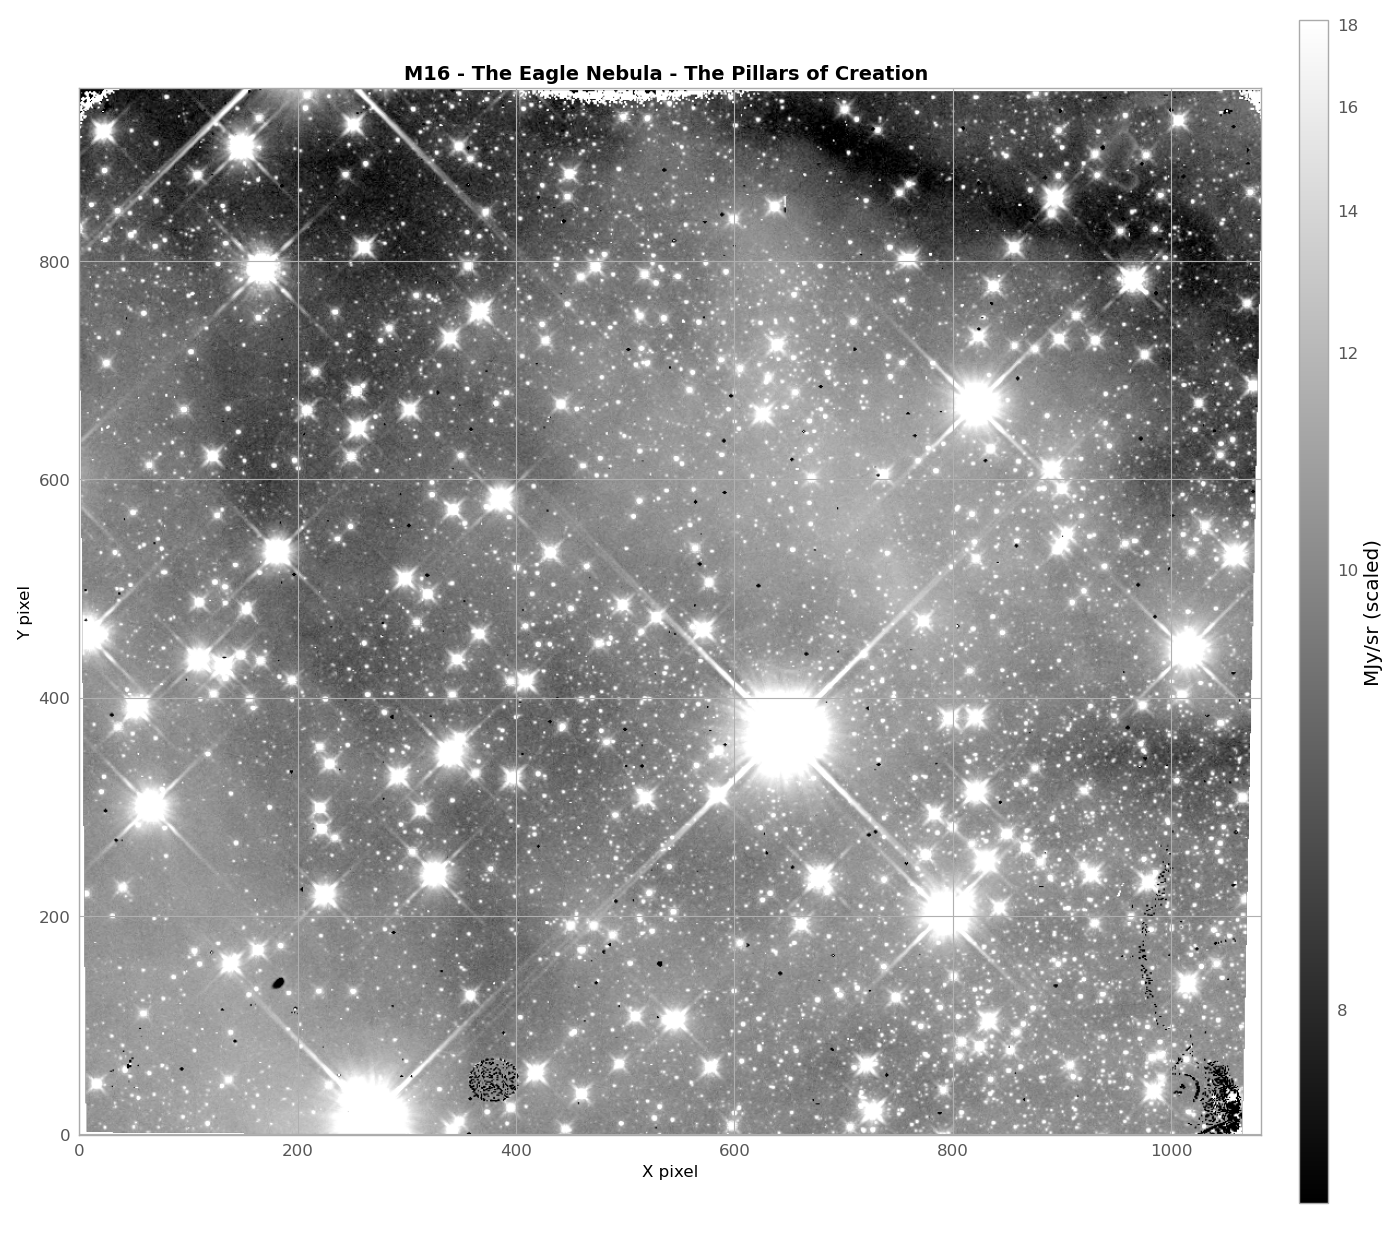

In [61]:
m16_image = ClusterAnalyzer(m16_file, m16_data, m16_hdu_list)
m16_image.show_image(m16_data, m16_file)

In [ ]:
from astropy.stats import sigma_clipped_stats 
import photutils
from photutils.detection import DAOStarFinder
mean,median,std=sigma_clipped_stats(m16_data, sigma=3.0)
print(mean,median,std)

daofind=DAOStarFinder(fwhm=3.0,threshold=5*std)
# find sources
sources=daofind(m16_data-median)
sources

In [ ]:
from photutils.aperture import CircularAperture #code from DESI ASTRO 
positions = np.transpose((sources['xcentroid'],sources['ycentroid']))
plt.figure(figsize=(fig_width, fig_height))
apertures=CircularAperture(positions,r=10)
apertures.plot(color='red',lw=5)

plt.imshow(m16_data, cmap='gray', origin='lower', norm=norm)
plt.colorbar(label='MJy/sr (scaled)', fraction=0.03, pad=0.03, aspect=40)
plt.title('M16 - The Eagle Nebula - The Pillars of Creation ', 
            fontsize=14, fontweight='bold')
plt.xlabel('X pixel', fontsize=12)
plt.ylabel('Y pixel', fontsize=12)
plt.tight_layout()
plt.show()

In [ ]:
x=1550
y=400
position=(x,y)
star_1=star_cutout(x,y,position)

## Color Magnitude Diagram

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

from astroquery.mast import Observations
from astroquery.mast import Catalogs
import pandas as pd
import astropy.io.fits as fits

In [68]:
m16_hdu_list.info()

Filename: C:\Users\mya\.astropy\cache\download\url\715233a8f11bfd011439fab978a69403\contents
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     853   ()      
  1  SCI           1 ImageHDU        94   (4253, 4659)   float32   
  2  WHT           1 ImageHDU        45   (4253, 4659)   float32   
  3  CTX           1 ImageHDU        40   (4253, 4659)   int32   
  4  HDRTAB        1 BinTableHDU    561   4R x 276C   [9A, 3A, K, D, D, D, D, D, D, D, D, D, D, D, D, K, 9A, 9A, 7A, 18A, 4A, D, D, D, D, 3A, D, D, D, D, D, D, D, D, D, D, D, D, K, K, 8A, 23A, D, D, D, D, K, K, 8A, 23A, 9A, 19A, 4A, K, D, D, D, K, K, K, K, 23A, D, D, D, D, K, K, 4A, 3A, 4A, L, D, D, D, 23A, 1A, K, D, D, D, 4A, 1A, 12A, 12A, 8A, 23A, D, D, 10A, 10A, D, D, D, 4A, 3A, 3A, 4A, 8A, 7A, D, K, D, 6A, 9A, 8A, D, D, 4A, 18A, 3A, K, 5A, 4A, D, 13A, 8A, 4A, 3A, D, D, D, 3A, 1A, D, 23A, D, D, D, 3A, L, 1A, 4A, D, 3A, 6A, D, D, D, D, D, 23A, D, D, D, D, D, 1A, K, K, K, K, D, 3A, K,

In [ ]:

magnitudes = m16_hdu_list[1].data["PSFMAG"] #potential key for accessing magnitudes from HDU list
magnitudes = np.array(magnitudes)

# Creating arrays for g-band and r-band magnitudes
g_band = magnitudes[:, 1]
r_band = magnitudes[:, 2]

# Calculating color (g - r)
color_data1 = g_band - r_band

# Plotting the CMD
plt.figure(figsize=(8, 6))
plt.scatter(color_data1, r_band, s=3, color="black", label="M13 data")
plt.ylim(10, 30)
plt.gca().invert_yaxis()
plt.xlim(-2, 2)
plt.title("CMD of M16")
plt.ylabel("Apparent Magnitude (r-band)")
plt.xlabel("Color (g - r)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

IndexError: only integers, slices (`:`), ellipsis (`...`), numpy.newaxis (`None`) and integer or boolean arrays are valid indices

In [84]:
print(m16_hdu_list[0].header)

SIMPLE  =                    T / conforms to FITS standard                      BITPIX  =                    8 / array data type                                NAXIS   =                    0 / number of array dimensions                     EXTEND  =                    T                                                  DATE    = '2025-08-14'         / date this file was written (yyyy-mm-dd)        COMMENT   FITS (Flexible Image Transport System) format is defined in 'AstronomyCOMMENT   and Astrophysics', volume 376, page 359; bibcode: 2001A&A...376..359H NEXTEND =                    4 / Number of standard extensions                  FILENAME= 'ick909040_drz.fits' / name of file                                   FILETYPE= 'SCI      '          / type of data found in data file                                                                                                TELESCOP= 'HST'                / telescope used to acquire data                 BSIDEOPS= 'FALSE'              / Post-20